# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [76]:
STUDENT_NAME = "Nguyễn Huỳnh Nam Quốc"  # TODO: Họ và tên
STUDENT_ID = "2453089"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Huỳnh Nam Quốc (2453089)


In [77]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\Nam Quoc\OneDrive\Documents\BK HCM\Full_Semester\HK253\Khóa học Machine Learning & IoT Lab\mliot-pyml-2026-hw-main\mliot-pyml-2026-hw-main\mliot-pyml-2026-hw-fork\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [78]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [79]:
# TODO N1
# shifted_logits = ...
# exp_logits = ...
# class_probabilities = ...
# predicted_classes = ...
# confidence_scores = ...
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)

exp_logits = np.exp(shifted_logits)

class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

predicted_classes = np.argmax(class_probabilities, axis=1)

confidence_scores = np.max(class_probabilities, axis=1)

print("shifted_logits:")
print(shifted_logits)

print("\nclass_probabilities:")
print(np.round(class_probabilities, 4))

print("\npredicted_classes:", predicted_classes)
print("confidence_scores:", np.round(confidence_scores, 4))

shifted_logits:
[[ 0.  -1.  -1.9]
 [-1.   0.  -2. ]
 [-5.  -4.   0. ]
 [ 0.   0.   0. ]]

class_probabilities:
[[0.659  0.2424 0.0986]
 [0.2447 0.6652 0.09  ]
 [0.0066 0.0179 0.9756]
 [0.3333 0.3333 0.3333]]

predicted_classes: [0 1 2 0]
confidence_scores: [0.659  0.6652 0.9756 0.3333]


In [80]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [81]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [82]:
# TODO N2
# train_feature_mean = ...
# train_feature_std = ...
# X_train_scaled = ...
# X_val_scaled = ...
train_feature_mean = X_train.mean(axis=0)

train_feature_std = X_train.std(axis=0)

train_feature_std = np.where(train_feature_std == 0, 1, train_feature_std)

X_train_scaled = (X_train - train_feature_mean) / train_feature_std

X_val_scaled = (X_val - train_feature_mean) / train_feature_std

print("train_feature_mean:", np.round(train_feature_mean, 4))
print("train_feature_std:", np.round(train_feature_std, 4))

print("\nX_train_scaled:")
print(np.round(X_train_scaled, 4))

print("\nX_val_scaled:")
print(np.round(X_val_scaled, 4))

train_feature_mean: [172.5     69.1667   1.65    28.1667]
train_feature_std: [ 7.4777 13.0437  0.7911  7.6467]

X_train_scaled:
[[-0.3343 -0.3194 -0.5688 -0.8064]
 [ 1.003   0.8305  0.9481  0.8936]
 [-1.6716 -1.4694 -1.0745 -1.1988]
 [ 0.3343  0.0639 -0.1896 -0.0218]
 [-0.6018 -0.7028 -0.8216 -0.5449]
 [ 1.2704  1.5972  1.7065  1.6783]]

X_val_scaled:
[[-0.0669 -0.0894 -0.316  -0.2833]
 [ 2.3403  1.9805  2.2121  2.2014]]


In [83]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [84]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [85]:
# TODO N3
# correct_mask = ...
# high_confidence_mask = ...
# review_mask = ...
# review_indices = ...
correct_mask = predicted_classes == true_labels

high_confidence_mask = confidence_scores >= confidence_threshold

review_mask = (~correct_mask) | (~high_confidence_mask)

review_indices = np.where(review_mask)[0]

print("predicted_classes:", predicted_classes)
print("true_labels:", true_labels)
print("confidence_scores:", np.round(confidence_scores, 4))

print("\ncorrect_mask:", correct_mask)
print("high_confidence_mask:", high_confidence_mask)
print("review_mask:", review_mask)
print("review_indices:", review_indices)

predicted_classes: [0 1 2 0]
true_labels: [0 2 2 1]
confidence_scores: [0.659  0.6652 0.9756 0.3333]

correct_mask: [ True False  True False]
high_confidence_mask: [False False  True False]
review_mask: [ True  True False  True]
review_indices: [0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [86]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [87]:
# TODO N4
# normalized_batch = ...
# augmented_batch = ...
# augmented_batch[0, 0, 0, 0] = ...
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

augmented_batch = np.flip(normalized_batch, axis=2).copy()

augmented_batch[0, 0, 0, 0] = 1.0

print("image_batch_uint8 dtype:", image_batch_uint8.dtype)
print("normalized_batch dtype:", normalized_batch.dtype)

print("normalized_batch shape:", normalized_batch.shape)
print("augmented_batch shape:", augmented_batch.shape)

print("normalized_batch min/max:", normalized_batch.min(), normalized_batch.max())
print("augmented_batch min/max:", augmented_batch.min(), augmented_batch.max())

print("Có dùng chung bộ nhớ không?", np.shares_memory(normalized_batch, augmented_batch))

image_batch_uint8 dtype: uint8
normalized_batch dtype: float32
normalized_batch shape: (2, 4, 4, 3)
augmented_batch shape: (2, 4, 4, 3)
normalized_batch min/max: 0.0 0.37254903
augmented_batch min/max: 0.0 1.0
Có dùng chung bộ nhớ không? False


# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
1. Mỗi dòng đại diện cho một mẫu xe trong bộ dữ liệu Automobile.
2. Ký hiệu missing value trong file CSV là dấu `?`.
3. `symboling` là mức đánh giá rủi ro bảo hiểm của xe, có giá trị từ -3 đến 3. Giá trị này cho biết mức độ rủi ro tương đối của xe theo góc nhìn bảo hiểm.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [88]:
# TODO D1
# raw_df = ...
# raw_shape = ...
# raw_missing_marker_count = ...
raw_df = pd.read_csv(DATA_PATH, dtype=str)

raw_shape = raw_df.shape

raw_missing_marker_count = (raw_df == "?").sum().sum()

display(raw_df.head())

print("raw_shape:", raw_shape)
print("raw_missing_marker_count:", raw_missing_marker_count)

print("\nDtypes khi chưa xử lý:")
print(raw_df.dtypes)

print("\nSố dấu ? theo từng cột:")
display((raw_df == "?").sum().sort_values(ascending=False).head(10))

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.50,...,152,mpfi,2.68,3.47,9.00,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.80,...,109,mpfi,3.19,3.40,10.00,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.40,...,136,mpfi,3.19,3.40,8.00,115,5500,18,22,17450


raw_shape: (205, 26)
raw_missing_marker_count: 59

Dtypes khi chưa xử lý:
symboling            object
normalized_losses    object
make                 object
fuel_type            object
aspiration           object
num_doors            object
body_style           object
drive_wheels         object
engine_location      object
wheel_base           object
length               object
width                object
height               object
curb_weight          object
engine_type          object
num_cylinders        object
engine_size          object
fuel_system          object
bore                 object
stroke               object
compression_ratio    object
horsepower           object
peak_rpm             object
city_mpg             object
highway_mpg          object
price                object
dtype: object

Số dấu ? theo từng cột:


normalized_losses    41
stroke                4
price                 4
bore                  4
horsepower            2
peak_rpm              2
num_doors             2
symboling             0
fuel_type             0
make                  0
dtype: int64

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [89]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [90]:
# TODO D2
# df_clean = ...
# for column in NUMERIC_COLUMNS:
#     ...
# missing_by_column = ...
df_clean = raw_df.replace("?", np.nan).copy()

for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

missing_by_column = df_clean.isna().sum().sort_values(ascending=False)

print("Dtypes sau khi xử lý:")
print(df_clean.dtypes)

print("\nMissing values theo từng cột:")
display(missing_by_column[missing_by_column > 0])

display(df_clean.head())

Dtypes sau khi xử lý:
symboling              int64
normalized_losses    float64
make                  object
fuel_type             object
aspiration            object
num_doors             object
body_style            object
drive_wheels          object
engine_location       object
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type           object
num_cylinders         object
engine_size            int64
fuel_system           object
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                float64
dtype: object

Missing values theo từng cột:


normalized_losses    41
stroke                4
price                 4
bore                  4
horsepower            2
peak_rpm              2
num_doors             2
dtype: int64

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
Không nên fill tất cả numeric columns bằng cùng một giá trị, vì mỗi cột có ý nghĩa và đơn vị khác nhau. Ví dụ `price` là giá xe theo USD, `horsepower` là mã lực, còn `peak_rpm` là vòng/phút, nên nếu dùng chung một giá trị để điền thì dữ liệu sẽ bị sai bản chất.

Với `price`, em nghĩ nên drop các dòng bị thiếu khi phân tích giá xe, vì `price` là biến rất quan trọng trong bài EDA này. Nếu tự fill giá xe bằng mean hoặc median thì biểu đồ phân phối giá và tương quan với các biến khác có thể bị méo.

Cột `normalized_losses` thiếu nhiều nhất, tới 41 giá trị, nên nếu phân tích riêng cột này thì cần rất cẩn thận. Nếu drop hết các dòng thiếu thì mất khá nhiều dữ liệu, còn nếu fill quá đơn giản thì kết quả có thể không phản ánh đúng dữ liệu thật.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [91]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [92]:
# TODO D3
# analysis_df = ...
# X_auto = ...
# auto_feature_mean = ...
# auto_feature_std = ...
# X_auto_scaled = ...
analysis_df = df_clean.dropna(subset=AUTO_FEATURES).copy()

X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)

auto_feature_mean = X_auto.mean(axis=0)

auto_feature_std = X_auto.std(axis=0)

auto_feature_std = np.where(auto_feature_std == 0, 1, auto_feature_std)

X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

print("analysis_df shape:", analysis_df.shape)
print("X_auto shape:", X_auto.shape)

print("\nauto_feature_mean:")
for name, value in zip(AUTO_FEATURES, auto_feature_mean):
    print(f"{name}: {value:.4f}")

print("\nauto_feature_std:")
for name, value in zip(AUTO_FEATURES, auto_feature_std):
    print(f"{name}: {value:.4f}")

print("\nMean của X_auto_scaled:")
print(np.round(X_auto_scaled.mean(axis=0), 4))

print("\nStd của X_auto_scaled:")
print(np.round(X_auto_scaled.std(axis=0), 4))

analysis_df shape: (199, 26)
X_auto shape: (199, 6)

auto_feature_mean:
curb_weight: 2556.0302
engine_size: 126.8241
horsepower: 103.3970
city_mpg: 25.2010
highway_mpg: 30.6834
price: 13243.4322

auto_feature_std:
curb_weight: 518.5477
engine_size: 41.6479
horsepower: 37.4594
city_mpg: 6.4356
highway_mpg: 6.8322
price: 7958.6354

Mean của X_auto_scaled:
[ 0.  0.  0. -0.  0. -0.]

Std của X_auto_scaled:
[1. 1. 1. 1. 1. 1.]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [93]:
# TODO D4
# price_index = ...
# price_z = ...
# price_outlier_mask = ...
# price_outliers = ...
price_index = AUTO_FEATURES.index("price")

price_values = X_auto[:, price_index]

price_z = (price_values - price_values.mean()) / price_values.std()

price_outlier_mask = np.abs(price_z) > 2

price_outliers = analysis_df.loc[
    price_outlier_mask,
    ["make", "body_style", "engine_size", "horsepower", "city_mpg", "highway_mpg", "price"]
].copy()

price_outliers["price_z"] = price_z[price_outlier_mask]

price_outliers = price_outliers.sort_values("price", ascending=False)

print("Số lượng price outliers:", price_outlier_mask.sum())
display(price_outliers)

Số lượng price outliers: 14


,make,body_style,engine_size,horsepower,city_mpg,highway_mpg,price,price_z
74,mercedes-benz,hardtop,304,184.0,14,16,45400.0,4.040463
16,bmw,sedan,209,182.0,16,22,41315.0,3.527184
73,mercedes-benz,sedan,308,184.0,14,16,40960.0,3.482578
128,porsche,convertible,194,207.0,17,25,37028.0,2.988523
17,bmw,sedan,209,182.0,15,20,36880.0,2.969927
49,jaguar,sedan,326,262.0,13,17,36000.0,2.859356
48,jaguar,sedan,258,176.0,15,19,35550.0,2.802813
72,mercedes-benz,convertible,234,155.0,16,18,35056.0,2.740742
71,mercedes-benz,sedan,234,155.0,16,18,34184.0,2.631176
127,porsche,hardtop,194,207.0,17,25,34028.0,2.611574


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [94]:
# TODO D5
# engine_price_corr = ...
# price_by_body_style = ...
engine_size_values = analysis_df["engine_size"].to_numpy(dtype=np.float64)
price_values = analysis_df["price"].to_numpy(dtype=np.float64)

engine_price_corr = np.corrcoef(engine_size_values, price_values)[0, 1]


price_by_body_style = (
    analysis_df
    .groupby("body_style")["price"]
    .mean()
    .sort_index()
)


price_by_body_style_summary = (
    analysis_df
    .groupby("body_style")["price"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("median", ascending=False)
)

print("engine_price_corr:", round(engine_price_corr, 4))

print("\nMean price theo body_style:")
display(price_by_body_style)

print("\nBảng thống kê phụ theo body_style:")
display(price_by_body_style_summary)

engine_price_corr: 0.8739

Mean price theo body_style:


body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9958.373134
sedan          14459.755319
wagon          12500.166667
Name: price, dtype: float64


Bảng thống kê phụ theo body_style:


,count,mean,median,std
body_style,,,,
hardtop,8,22208.500000,19687.5,14555.520749
convertible,6,21890.500000,17084.5,11187.802193
wagon,24,12500.166667,11992.0,5189.942629
sedan,94,14459.755319,11078.5,8523.210259
hatchback,67,9958.373134,8499.0,4180.169617


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

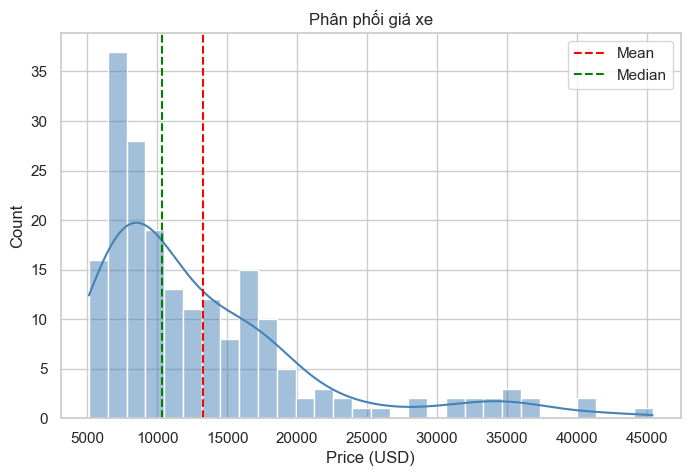

In [95]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(8, 5))

sns.histplot(data=analysis_df, x="price", kde=True, bins=30, color="steelblue")

plt.axvline(analysis_df["price"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(analysis_df["price"].median(), color="green", linestyle="--", label="Median")

plt.title("Phân phối giá xe")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.legend()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Giá xe bị lệch phải khá rõ, phần lớn xe nằm ở vùng giá thấp đến trung bình, còn một số ít xe giá rất cao kéo đuôi phân phối sang phải. Vì vậy mean có xu hướng lớn hơn median.

## M2.2 Dataset có cân bằng theo body style không?

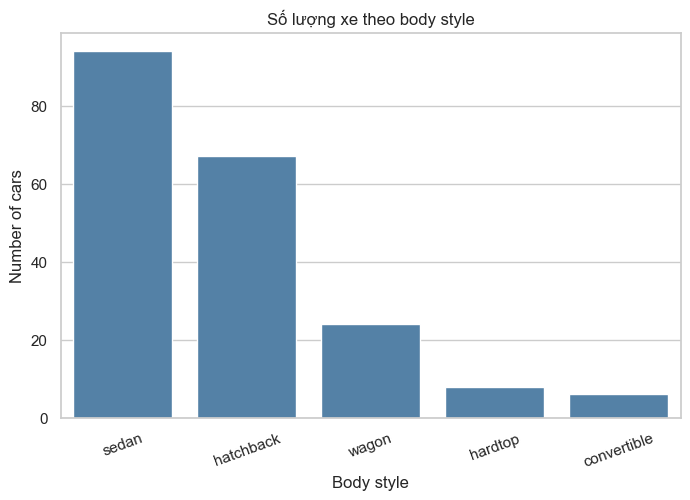

In [96]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(8, 5))

order = analysis_df["body_style"].value_counts().index

sns.countplot(data=analysis_df, x="body_style", order=order, color="steelblue")

plt.title("Số lượng xe theo body style")
plt.xlabel("Body style")
plt.ylabel("Number of cars")
plt.xticks(rotation=20)
plt.show()

**Nhận xét:** <!-- 1--2 câu --> 
Dataset không cân bằng theo body style. Sedan và hatchback xuất hiện nhiều nhất, trong khi convertible và hardtop có số lượng rất ít.

## M2.3 Price khác nhau theo body style ra sao?

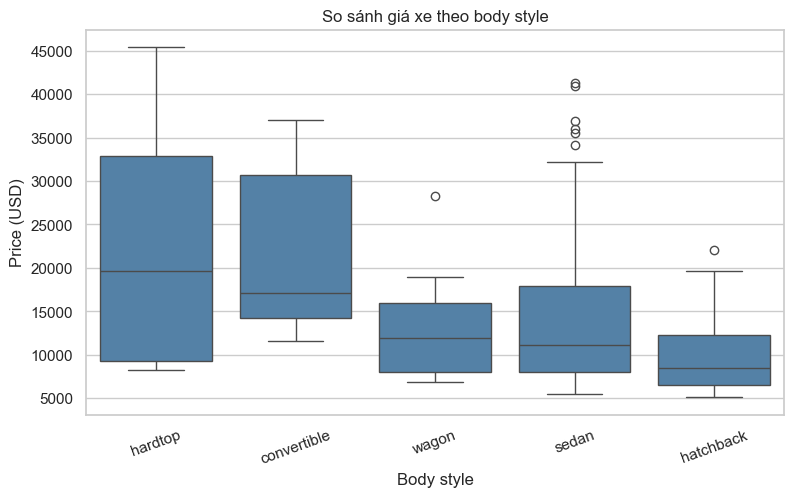

In [97]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(9, 5))

order = price_by_body_style_summary.index

sns.boxplot(data=analysis_df, x="body_style", y="price", order=order, color="steelblue")

plt.title("So sánh giá xe theo body style")
plt.xlabel("Body style")
plt.ylabel("Price (USD)")
plt.xticks(rotation=20)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Hardtop và convertible có median price khá cao, nhưng số lượng mẫu ít nên cần đọc kết quả cẩn thận. Hatchback thường có giá thấp hơn, còn sedan có độ phân tán giá khá rộng vì gồm cả xe phổ thông và xe đắt tiền.

## M2.4 Engine size liên quan thế nào tới price?

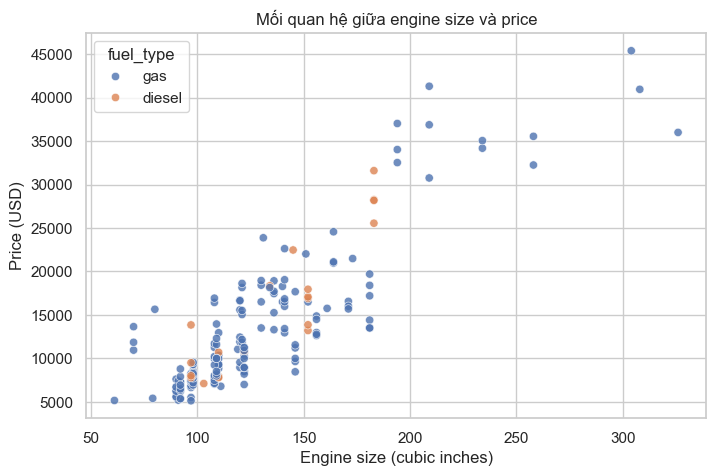

In [98]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=analysis_df,
    x="engine_size",
    y="price",
    hue="fuel_type",
    alpha=0.8
)

plt.title("Mối quan hệ giữa engine size và price")
plt.xlabel("Engine size (cubic inches)")
plt.ylabel("Price (USD)")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Engine size càng lớn thì price thường càng cao. Quan hệ này khá rõ, dù vẫn có một số điểm lệch do giá xe còn phụ thuộc vào hãng, body style và nhiều đặc điểm khác.

## M2.5 Các feature numeric tương quan ra sao?

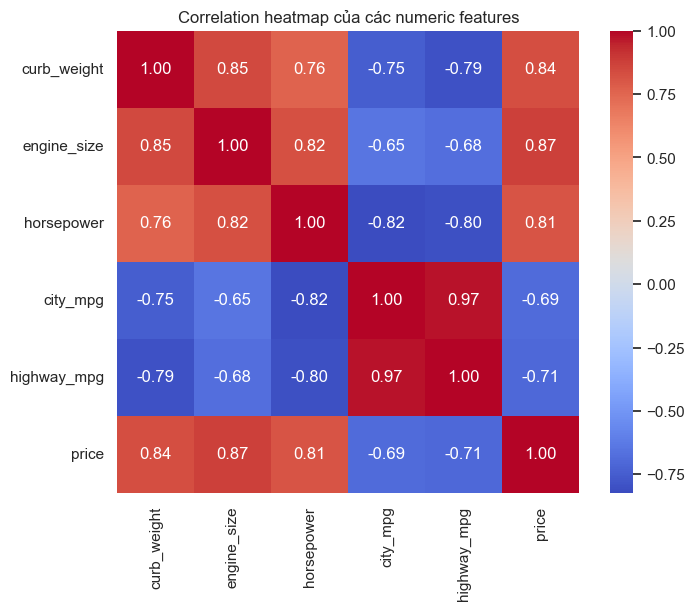

In [99]:
# TODO M2.5: correlation heatmap
corr_matrix = analysis_df[AUTO_FEATURES].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation heatmap của các numeric features")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->`engine_size`, `curb_weight` và `horsepower` tương quan dương khá mạnh với `price`. Ngược lại, `city_mpg` và `highway_mpg` tương quan âm với `price`, nghĩa là xe càng tiết kiệm nhiên liệu thì thường có giá thấp hơn trong bộ dữ liệu này.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

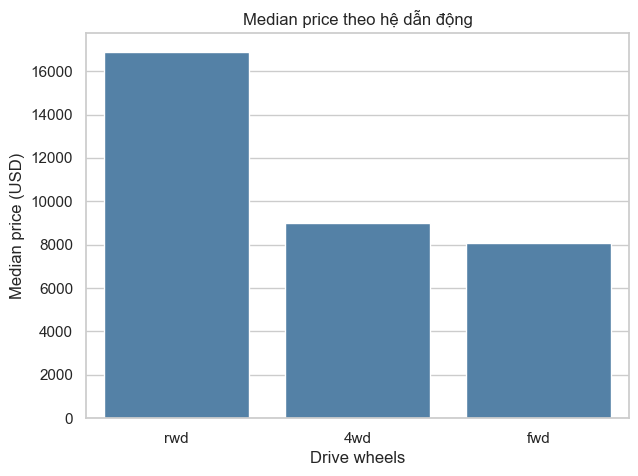

drive_wheels
rwd    16900.0
4wd     9005.5
fwd     8094.0
Name: price, dtype: float64

In [100]:
# TODO M2.6: biểu đồ tự chọn
drive_price = (
    analysis_df
    .groupby("drive_wheels")["price"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=drive_price.index,
    y=drive_price.values,
    color="steelblue"
)

plt.title("Median price theo hệ dẫn động")
plt.xlabel("Drive wheels")
plt.ylabel("Median price (USD)")
plt.show()

display(drive_price)

**Nhận xét:** <!-- 1--2 câu -->
Xe dẫn động cầu sau `rwd` có median price cao hơn so với `fwd` và `4wd`. Điều này khá hợp lý vì nhiều xe hiệu năng cao hoặc xe đắt tiền trong dataset dùng hệ dẫn động cầu sau.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->
Qua bài EDA này, em rút ra một vài điểm chính từ dataset Automobile. Đầu tiên, giá xe không phân phối đều mà bị lệch phải khá rõ. Phần lớn xe nằm ở vùng giá thấp đến trung bình, trong khi một số xe cao cấp có giá rất cao và bị xem là outlier theo z-score.

Thứ hai, các biến liên quan đến kích thước và sức mạnh xe như `engine_size`, `curb_weight` và `horsepower` có tương quan dương khá mạnh với `price`. Trong đó, `engine_size` có correlation khoảng 0.8739 với giá xe, cho thấy xe có động cơ lớn thường có giá cao hơn. Ngược lại, `city_mpg` và `highway_mpg` tương quan âm với `price`, nghĩa là trong bộ dữ liệu này các xe tiết kiệm nhiên liệu hơn thường có xu hướng rẻ hơn.

Thứ ba, khi so sánh theo `body_style`, sedan và hatchback xuất hiện nhiều nhất, còn convertible và hardtop có rất ít mẫu. Vì vậy khi thấy hardtop hoặc convertible có median price cao, em cần đọc kết quả cẩn thận vì số lượng mẫu của hai nhóm này khá nhỏ. Ngoài ra, nhóm xe dẫn động cầu sau `rwd` có median price cao hơn `fwd` và `4wd`, có thể vì nhóm này chứa nhiều xe mạnh hoặc xe cao cấp hơn.

Dataset này vẫn có một số hạn chế. Một là dữ liệu có missing values, đặc biệt `normalized_losses` thiếu khá nhiều. Hai là số lượng mẫu giữa các nhóm không cân bằng, ví dụ sedan/hatchback nhiều hơn hẳn convertible/hardtop. Ngoài ra, correlation không đồng nghĩa với causation: `engine_size` tương quan cao với `price`, nhưng không thể kết luận chỉ riêng engine size làm giá xe tăng, vì giá còn phụ thuộc vào hãng xe, phân khúc, body style, trang bị và nhiều yếu tố khác.

Nếu phân tích tiếp, em muốn tìm hiểu câu hỏi: trong các yếu tố như `make`, `engine_size`, `horsepower`, `curb_weight` và `drive_wheels`, yếu tố nào ảnh hưởng mạnh nhất đến giá xe khi xét đồng thời nhiều biến với nhau?